### Анализ факторов, влияющих на рейтинг фильмов: от жанра до названия

**Описание**:

Данный проект посвящён анализу фильмов из подборки топа на сайте [FilmPro](https://www.filmpro.ru/movies/top).
Данные были собраны с помощью автоматического парсинга с нескольких страниц сайта, включая индивидуальные карточки фильмов.

Цель исследования — изучить, какие характеристики фильма влияют на его рейтинг, включая:

- жанр, страну производства и авторов (режиссёр, сценарист и др.)
- хронометраж, число зрительских голосов и кассовые сборы
- особенности заголовков фильмов — их длину и часто встречающиеся слова

Анализ охватывает как структурированные признаки, так и текстовые (названия), включая лемматизацию и частотный анализ.
Выводы визуализированы в формате графиков и сопровождаются обоснованными интерпретациями.

Проект построен с упором на воспроизводимость и расширяемость — подход легко адаптируется под аналитику сериалов, книг, подкастов и др.


In [1]:
import json
from pathlib import Path
import sys
import os
import ast
import pandas as pd

from selenium import webdriver

# Добавляем корень проекта в sys.path
project_root = Path(os.getcwd()).parents[0]  # т.к. ноутбук в /notebooks/
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from scripts.parser import scrape_top_movies, scrape_movie_details
from scripts.clean_data import clean_movie_data, save_clean_data
from scripts.inspect_details import inspect_details
from scripts.eda import describe_dataset, plot_rating_distribution, plot_vote_distribution, plot_log_vote_distribution, plot_year_distribution
from scripts.analysis import (plot_avg_rating_by_genre, plot_avg_rating_by_director, plot_avg_rating_by_country,
                              plot_rating_vs_votes, plot_rating_vs_runtime, plot_rating_vs_popularity,
                              plot_rating_vs_title_length, plot_top_lemmas, compare_lemmas_by_rating)


# Загрузка данных

## Этап 1: Парсинг списка фильмов (страницы топа)

Мы начали с парсинга подборки фильмов на сайте [filmpro.ru/movies/top](https://filmpro.ru/movies/top). Для этого использовали **Selenium** в связке с **WebDriver Manager** для автоматической загрузки и управления Chrome-драйвером.

**Что парсим:**
- Каждая страница содержит 60 фильмов
- Каждый фильм находится в `div.b-maintopfilms__item`
- Название и ссылка на страницу фильма — в `a.b-maintopfilms__titlelink`

**Архитектурные решения:**
- Создали отдельную функцию `scrape_top_movies()` в `scripts/parser.py`
- Используем параметр `num_pages` для обхода нескольких страниц (`?page=1`, `?page=2`, …)
- Результаты сохраняем в `data/raw/movies_list.json`

**Проблемы и их решения:**
- Иногда страница загружалась, но карточки фильмов отсутствовали (страница грузится быстро, а контент на ней иногда
 подгружается дольше, lazyload): добавили повторную попытку загрузки карточек (до 3 попыток с паузой 5 секунд).

---

## Этап 2: Парсинг страниц фильмов

После получения ссылок мы переходим на каждую страницу фильма и извлекаем подробности.

**Что извлекаем:**
- Рейтинг фильма: `div.b-film-rate__stats > h3`
- Количество голосов: `div.b-film-rate__stats > span`
- Метаданные: каждый параметр (`Год`, `Страна`, `Жанр`, и т.д.) находится в `div.b-film-imprint__item`, где:
  - название → `p.b-film-imprint__var`
  - значение → `p.b-film-imprint__val`

**Технические решения:**
- Функция `scrape_movie_details()` загружает `movies_list.json` и парсит каждую страницу
- Повторная попытка парсинга страницы, если не найден блок с рейтингом (до 3 раз)
- Собранные данные сохраняются в `data/raw/movie_details.json`

**Формат данных:**

```json
  {
    "title": "Золотая перчатка",
    "url": "https://www.filmpro.ru/movies/343787",
    "rating": "9.8",
    "votes": "6293",
    "details": {
      "Год": "2019",
      "Страна": "Германия, Франция",
      "Жанр": "Драма, Триллер, Ужасы, Криминал",
      "Режиссер": "Фатих Акин",
      "Дата релиза в РФ": "30 мая 2019",
      "Продюсер": "Фатих Акин, Клаус Спиннлер",
      "Сценарист": "Фатих Акин, Хайнц Штрунк",
      "Монтажер": "Эндрю Бёрд",
      "Оператор": "Райнер Клаусманн",
      "Художник-постановщик": "Тамо Кунц",
      "Хронометраж": "115 мин.",
      "Основной прокатчик": "Русский Репортаж",
      "Мировая премьера": "7 февраля 2019"
    }
  }
```

**Парсинг каждой страницы может занимать много времени.** В репозитории уже есть готовые данные, для запуска анализа
заново парсить страницы нет необходимости. Но для возможности репрезентации данных ниже вставлены блоки кода для
запуска парсинга.


In [14]:
# Парсинг списка фильмов с первых 3 страниц и сохранение в JSON
try:
    movies = scrape_top_movies(num_pages=3, delay=1, headless=True)
except KeyboardInterrupt:
    try:
        webdriver.Chrome().quit()
    except:
        pass
    print("⛔️ Прерывание вручную. Драйвер закрыт.")


In [15]:
# Парсинг детальной информации по каждому фильму
try:
    scrape_movie_details(delay=0.5, headless=True)
except KeyboardInterrupt:
    try:
        webdriver.Chrome().quit()
    except:
        pass
    print("⛔️ Прерывание вручную. Драйвер закрыт.")



## Очистка данных и подготовка к анализу

#### Общая цель

Цель этапа — привести данные о фильмах к формату, пригодному для анализа и визуализации. Исходные данные были получены с помощью парсинга и сохранены в `data/raw/movie_details.json`. Файл содержит список фильмов, для каждого из которых представлены:

- основная информация (название, ссылка, рейтинг, количество голосов)
- вложенные поля `details`, содержащие разнородные характеристики (год, жанр, страна, сборы, хронометраж и др.)

---

#### Предварительная разведка данных

Для изучения структуры блока `details` был написан отдельный скрипт `inspect_details.py`. Он:

- загружает `movie_details.json`
- выводит список всех уникальных полей в `details`
- показывает пример значения и частоту появления каждого поля

Это позволило:
- оценить полноту заполнения каждого поля
- принять решение об исключении редких признаков, не пригодных для анализа (например, поля, встречающиеся менее чем у 10% фильмов)

---

#### Критерии отбора и очистки

1. **Оставлены только часто встречающиеся поля**, представляющие потенциальную аналитическую ценность:
   - Жанр
   - Режиссер
   - Продюсер
   - Сценарист
   - Композитор
   - Страна
   - Монтажер
   - Художник-постановщик
   - Оператор
   - Формат
   - Год
   - Хронометраж
   - Сборы (в России, в мире, в США)
   - Бюджет
   - Зрители в России
   - Даты премьер (в РФ, мире)

2. **Исключены поля со слишком низкой встречаемостью** (менее 5–10 фильмов), такие как:
   - Оригинальный дизайн персонажей
   - Автор оригинала
   - Релиз на DVD
   - Релиз на Blu-Ray
   - Дата ре-релиза в РФ
   - Исполнение главной музыкальной темы и др.

---

#### Методы обработки данных

- **Строки с перечислениями** (жанры, режиссеры, страны и т.д.) были разбиты на списки по запятой.
- **Числовые значения**, содержащие символы (`$`, пробелы, `мин.`), были очищены и преобразованы в `int` (например, бюджет, сборы, хронометраж).
- **Даты** в формате `день месяц год` были приведены к `int`, оставляя только год (например, `"4 апреля 2019"` → `2019`).
- **Поля, содержащие оценку и количество голосов**, были предварительно нормализованы при парсинге (например, `"9.2 (324 голоса)"` → `rating=9.2`, `votes=324`).
- **Названия фильмов** были обработаны через лемматизацию и токенизацию с помощью библиотеки spaCy (`ru_core_news_sm`):
  - из названия извлекаются только алфавитные слова
  - все слова преобразуются к леммам
  - результат сохраняется в поле `title_lemmas` как список

---

#### Основные функции

Очистка реализована в модуле `scripts/clean_data.py`. Ключевые функции:

- `clean_movie_data(raw_data)` — принимает список словарей, возвращает `pandas.DataFrame`
- `save_clean_data(df)` — сохраняет итоговый DataFrame в `data/processed/movies_clean.csv`

Для обработки отдельных полей используются вспомогательные функции:
- `to_list()`, `clean_money()`, `extract_year()`, `clean_runtime()`, `lemmatize_title()`

---

#### Проблемы и их решения

- **Неструктурированность данных**: значения в `details` были представлены в виде неунифицированных строк — потребовалось регулярное выражение и ручной парсинг.
- **Отсутствие единообразия в дате**: иногда использовался формат вида "1 января 2020", применено регулярное
извлечение года.
- **Множественные значения в одном поле**: использована разбивка через запятую и удаление пробелов.
- **Низкое качество части данных**: решено исключать редкие поля, чтобы не усложнять анализ неинформативными признаками.
- **Разный язык и падежи в названиях**: лемматизация помогает унифицировать лексемы при анализе текстов.

---

#### Результат

В результате обработки был сформирован очищенный `DataFrame`, содержащий числовые, категориальные и текстовые признаки, пригодные для анализа. Данные сохранены в `data/processed/movies_clean.csv`.


In [2]:
# Вывод уникальных ключей в `movie_details.json` внутри `details` с примерами значений

json_path = project_root / "data" / "raw" / "movie_details.json"
inspect_details(json_path)

Поле                           Пример значения                          Встречаемость
------------------------------------------------------------------------------------------
Год                            2018                                     180
Дата релиза в РФ               4 апреля 2019                            180
Жанр                           Комедия                                  179
Режиссер                       Кирилл Соколов                           175
Хронометраж                    100 мин.                                 174
Основной прокатчик             Парадиз                                  174
Продюсер                       Софико Кикнавелидзе, Елена Геладзе       159
Сценарист                      Кирилл Соколов                           158
Страна                         Россия                                   152
Мировая премьера               7 февраля 2019                           151
Сборы в России                 $ 2 644 182                     

In [2]:
"""
Очистка и подготовка данных к анализу. Вывод примеров значений.
"""

# Загрузка сырых данных
with open("../data/raw/movie_details.json", "r", encoding="utf-8") as f:
    raw_movies = json.load(f)

# Очистка и преобразование
df = clean_movie_data(raw_movies)

# Сохранение
save_clean_data(df)

# Просмотр примера
df.head()

,title,url,rating,votes,title_lemmas,Жанр,Режиссер,Продюсер,Сценарист,Композитор,...,Сборы в России,Зрители в России,Бюджет,Сборы в мире,Сборы в США,Дата релиза в РФ,Мировая премьера,Релиз на DVD,Релиз на Blu-Ray,Дата ре-релиза в РФ
0,"Папа, сдохни",https://www.filmpro.ru/movies/342811,9.9,10467,"[папа, сдохнуть]",[Комедия],[Кирилл Соколов],"[Софико Кикнавелидзе, Елена Геладзе]",[Кирилл Соколов],[],...,NaN,NaN,NaN,NaN,NaN,2019,NaN,NaN,NaN,NaN
1,Золотая перчатка,https://www.filmpro.ru/movies/343787,9.8,6293,"[золотой, перчатка]","[Драма, Триллер, Ужасы, Криминал]",[Фатих Акин],"[Фатих Акин, Клаус Спиннлер]","[Фатих Акин, Хайнц Штрунк]",[],...,NaN,NaN,NaN,NaN,NaN,2019,2019.0,NaN,NaN,NaN
2,Шевели ластами 2,https://www.filmpro.ru/movies/8556,9.5,169,"[шевели, ласт]","[Мультфильм, Приключения]","[Бен Стассен, Винсент Кестелут]","[Домоник Парис, Джина Галло, Мими Мэйнард]",[Домоник Парис],[Рамин Джавади],...,2644182.0,447321.0,NaN,NaN,NaN,2012,2012.0,2013.0,2013.0,NaN
3,Упс... Ной уплыл!,https://www.filmpro.ru/movies/334010,9.5,170,"[упс, ной, уплыть]","[Комедия, Мультфильм, Приключения]","[Тоби Генкель, Шон МакКормак]","[Жан Гуссен, Яна Бол, Эмели Кристианс]","[Марк Ходкинсон, Тоби Генкель, Франциска Фриде]",[Стефен МакКеон],...,1291796.0,452640.0,NaN,NaN,NaN,2015,2015.0,NaN,NaN,NaN
4,Ледниковый период 2: Глобальное потепление,https://www.filmpro.ru/movies/8843,9.5,316,"[ледниковый, период, глобальный, потепление]","[Боевик, Мультфильм, Приключения]",[Карлос Салдана],[],[],[Уилл Эванс],...,17255243.0,4423445.0,80000000.0,623829763.0,195330621.0,2006,2006.0,2011.0,NaN,NaN


### Подготовка данных завершена

Фильмы успешно собраны, очищены и сохранены в удобный табличный формат.
На этом этапе:

- удалены или приведены к нужному типу неинформативные и нерелевантные поля
- строки с перечислениями (жанры, создатели и т.п.) преобразованы в списки
- числовые признаки очищены от единиц измерения и символов
- даты приведены к году
- названия фильмов лемматизированы для последующего текстового анализа

Теперь данные готовы для первичного визуального и статистического анализа.
Переходим к этапу **разведочного анализа данных (EDA)**.


#### Описание доступных переменных

В таблице приведён обзор всех колонок в наборе данных:

- тип данных (строка, число, список и т.п.)
- количество и доля пропущенных значений в % и в формате n/N

Это помогает:
- оценить, какие переменные числовые или категориальные
- принять решения о заполнении или исключении пропусков
- корректно построить визуализации и модели



In [2]:
# Загрузка данных
df = pd.read_csv("../data/processed/movies_clean.csv", converters={
    "Режиссер": ast.literal_eval,
    "Жанр": ast.literal_eval,
    "Продюсер": ast.literal_eval,
    "Сценарист": ast.literal_eval,
    "Композитор": ast.literal_eval,
    "Монтажер": ast.literal_eval,
    "Оператор": ast.literal_eval,
    "Страна": ast.literal_eval,
    "Формат": ast.literal_eval,
    "title_lemmas": ast.literal_eval
})

describe_dataset(df)

,Тип данных,Количество пропусков,Доля пропусков (%)
Всего фильмов: 180,,,
Дата ре-релиза в РФ,float64,177,98.33
Релиз на Blu-Ray,float64,150,83.33
Формат,object,140,77.78
Сборы в США,float64,136,75.56
Сборы в мире,float64,129,71.67
Бюджет,float64,114,63.33
Релиз на DVD,float64,90,50.00
Оператор,object,75,41.67
Монтажер,object,71,39.44


#### Распределение рейтингов и количества оценок

Гистограмма рейтингов показывает, какие оценки наиболее характерны для фильмов в выборке. Часто можно наблюдать нормальное или скошенное распределение.

Гистограмма количества голосов позволяет оценить, насколько надёжны рейтинги: фильмы с малым числом оценок могут иметь неустойчивые значения.

Оригинальное распределение количества голосов оказалось сильно скошенным: большинство фильмов имеют очень мало оценок, а несколько популярных фильмов — очень много. Это делает график трудночитаемым.

Чтобы улучшить интерпретацию, мы применили логарифмическое преобразование `log10(votes + 1)`. Теперь:

- Фильмы с 10 голосами будут отображаться на позиции `log10(11) ≈ 1.04`
- Фильмы со 100 голосами → около `2.0`
- Фильмы с 1000 голосами → около `3.0`
- И так далее

Такой подход:
- уменьшает влияние выбросов (сверхпопулярных фильмов),
- позволяет визуально различить группы фильмов с низким, средним и высоким уровнем голосования,
- даёт представление о распределении популярности фильмов.

График помогает ответить на вопрос: **насколько популярны фильмы в выборке и как часто встречаются редкие/массовые случаи?**

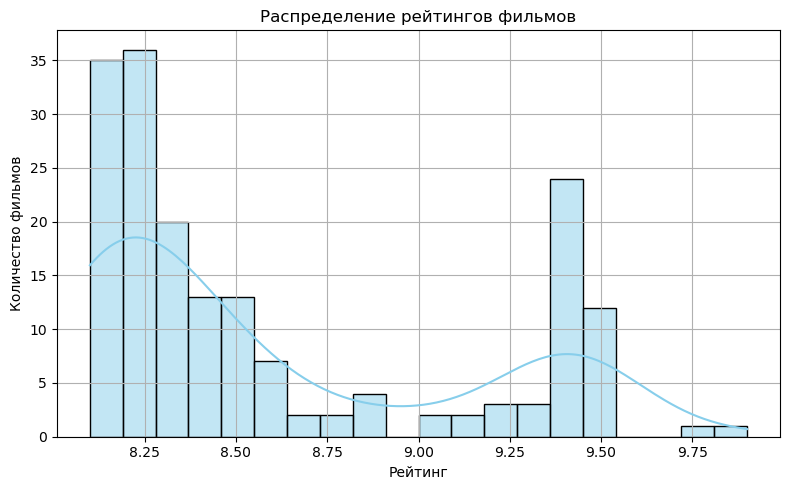

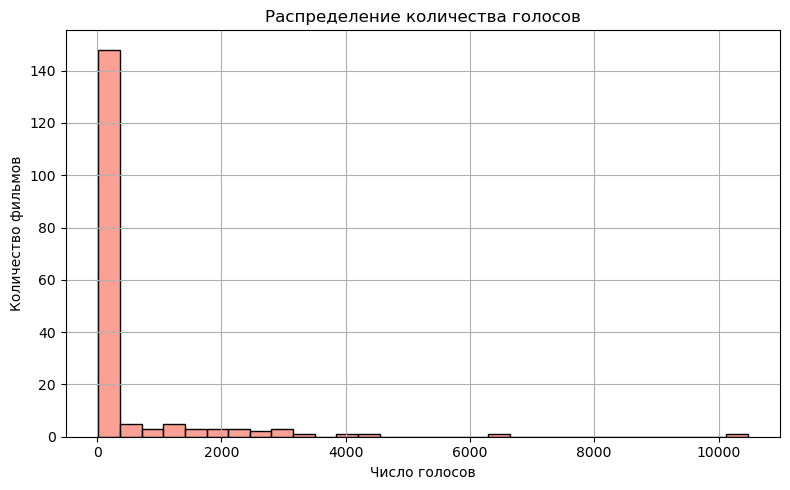

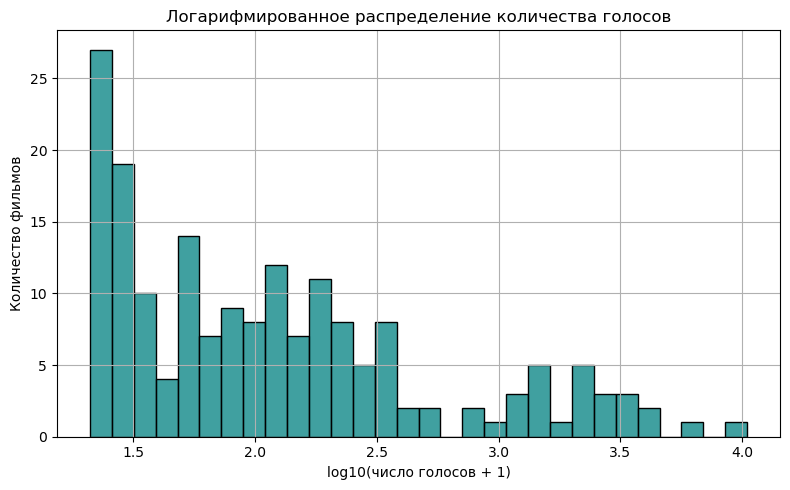

In [3]:
# Загрузка данных
df = pd.read_csv("../data/processed/movies_clean.csv", converters={
    "Режиссер": ast.literal_eval,
    "Жанр": ast.literal_eval,
    "Продюсер": ast.literal_eval,
    "Сценарист": ast.literal_eval,
    "Композитор": ast.literal_eval,
    "Монтажер": ast.literal_eval,
    "Оператор": ast.literal_eval,
    "Страна": ast.literal_eval,
    "Формат": ast.literal_eval,
    "title_lemmas": ast.literal_eval
})

# Гистограмма рейтингов
plot_rating_distribution(df)

# Гистограмма количества оценок
plot_vote_distribution(df)

# Логарифмированное распределение количества голосов
plot_log_vote_distribution(df)

#### Распределение фильмов по годам

Построим распределение количества фильмов по годам для трёх параметров:

- год производства (`Год`)
- дата выхода в прокат в РФ (`Дата релиса в РФ`)
- дата мировой премьеры (`Мировая премьера`)

Эти графики позволяют выявить тренды: рост или спад количества выпускаемых фильмов по годам, сезонность, влияние на рейтинг по времени выпуска и др.


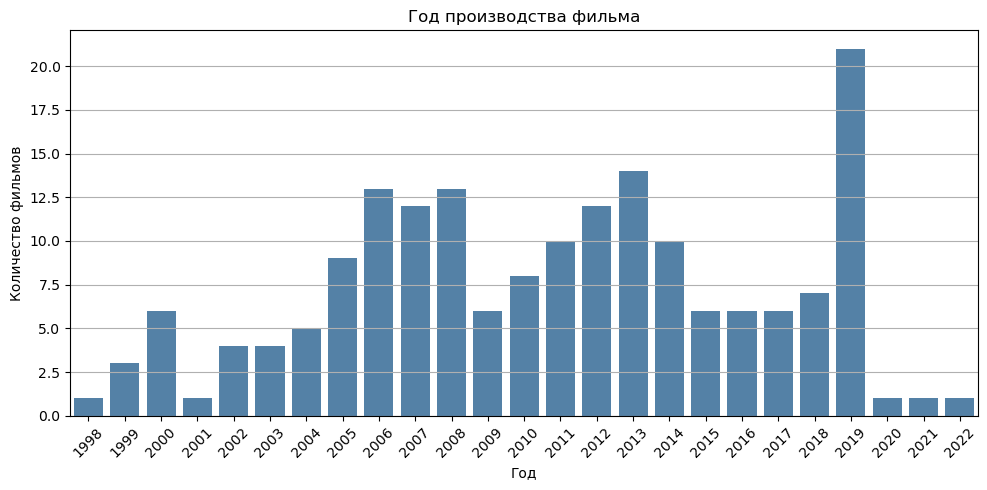

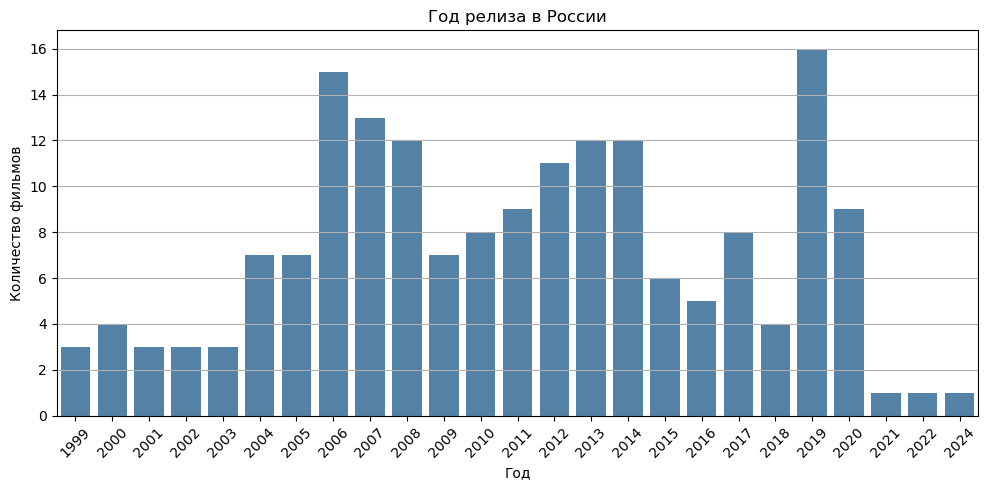

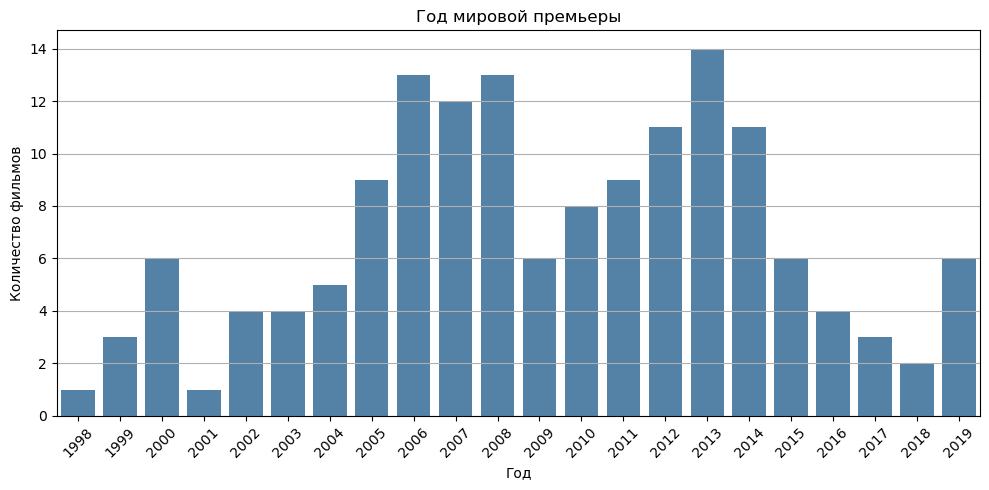

In [4]:
# Загрузка данных
df = pd.read_csv("../data/processed/movies_clean.csv", converters={
    "Режиссер": ast.literal_eval,
    "Жанр": ast.literal_eval,
    "Продюсер": ast.literal_eval,
    "Сценарист": ast.literal_eval,
    "Композитор": ast.literal_eval,
    "Монтажер": ast.literal_eval,
    "Оператор": ast.literal_eval,
    "Страна": ast.literal_eval,
    "Формат": ast.literal_eval,
    "title_lemmas": ast.literal_eval
})

plot_year_distribution(df, column="Год", title="Год производства фильма")
plot_year_distribution(df, column="Дата релиза в РФ", title="Год релиза в России")
plot_year_distribution(df, column="Мировая премьера", title="Год мировой премьеры")

#### Заключение по результатам разведочного анализа данных (EDA)

##### Общее состояние данных

В датасете содержится 180 фильмов с разнообразной информацией:
- рейтинги, число голосов, год производства
- даты релизов в России и в мире
- информация о жанрах, создателях, хронометраже, бюджете и сборах

Некоторые поля, такие как `rating`, `votes`, `Год`, заполнены полностью, другие — частично (например, `Сборы в США`, `Бюджет`, `Мировая премьера`).

---

##### Основные наблюдения

1. **Распределение рейтингов**:
   - большинство фильмов имеют рейтинг от 8.0 до 8.5
   - есть небольшая группа фильмов с крайне высокими рейтингами (> 9.0)

2. **Число голосов**:
   - большинство фильмов получили менее 100 голосов
   - распределение крайне смещено; после логарифмирования становится равномернее и информативнее

3. **Распределение по годам**:
   - по полю `Год` (производство) пик приходится на 2019 год
   - по полям `Дата релиза в РФ` и `Мировая премьера` пики — на 2006–2013 годы

   **Возможные причины расхождения**:
   - неполные или отсутствующие данные по дате мировой премьеры
   - задержки между производством и релизом
   - приоритет в подборке мог быть отдан свежим фильмам
   - часть фильмов, произведённых в 2019, могла не выйти официально в прокат в том году или совсем не выйти в прокат

---

##### Проблемы и их решение

- **Пропущенные значения**: для некоторых признаков доля пропусков превышает 70%; они будут использоваться выборочно
- **Сильная асимметрия в распределениях**: решена применением логарифмирования
- **Неструктурированные строки (жанры, имена)**: преобразованы в списки

---

Данные очищены, нормализованы и готовы к последующему анализу зависимостей.


## Анализ и визуализация

Весь мыслительный процесс, связанный с аналитикой ваших данных, а также построения визуализаций поместите в данный раздел

#### Средний рейтинг по жанрам

Этот график показывает, какие жанры в нашей выборке получают наиболее высокие (или низкие) оценки.
Мы исключаем редкие жанры (менее чем в 5 фильмах), чтобы не искажать картину.
Результат позволяет сделать выводы о предпочтениях аудитории по типу контента.


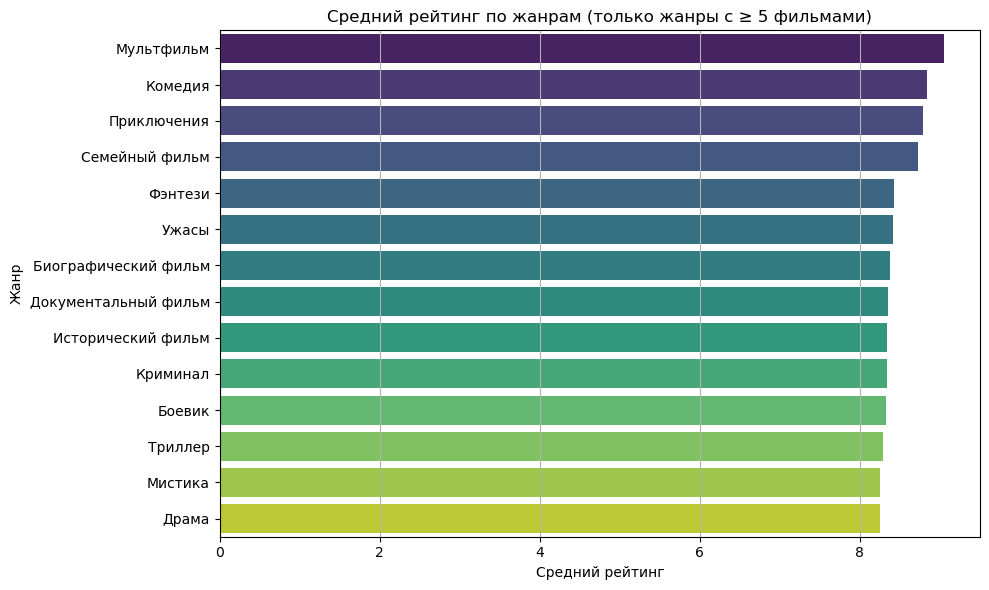

In [3]:
# Загрузка данных
df = pd.read_csv("../data/processed/movies_clean.csv", converters={
    "Режиссер": ast.literal_eval,
    "Жанр": ast.literal_eval,
    "Продюсер": ast.literal_eval,
    "Сценарист": ast.literal_eval,
    "Композитор": ast.literal_eval,
    "Монтажер": ast.literal_eval,
    "Оператор": ast.literal_eval,
    "Страна": ast.literal_eval,
    "Формат": ast.literal_eval,
    "title_lemmas": ast.literal_eval
})

plot_avg_rating_by_genre(df, min_count=5)

#### Средний рейтинг по режиссёрам

Этот график показывает, какие режиссёры чаще всего создают высоко оценённые фильмы.
Чтобы исключить случайные выбросы, в анализ включаются только те режиссёры, у которых не менее 2 фильмов в выборке.
Это позволяет выявить стабильных лидеров по качеству контента.


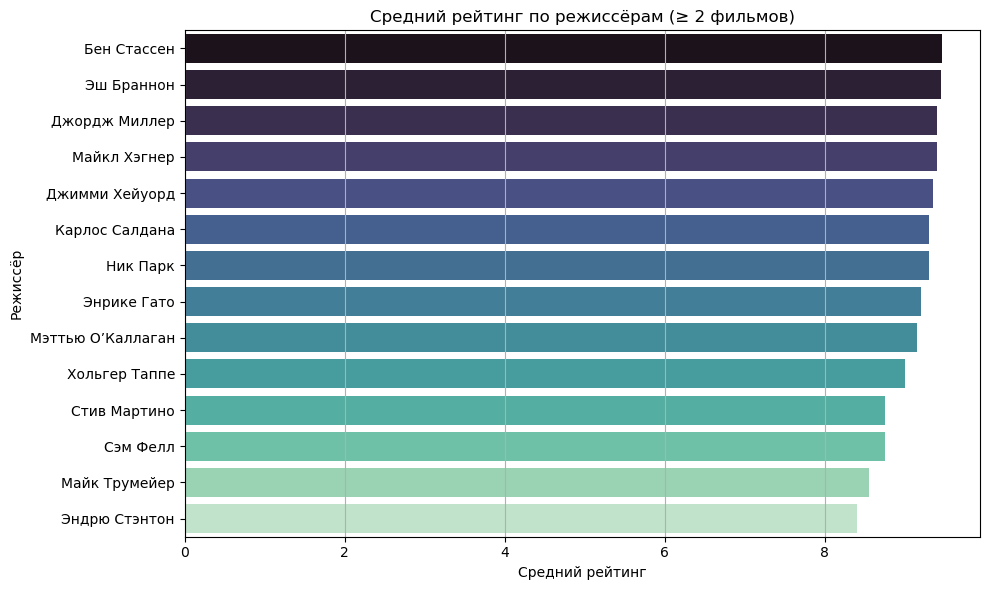

In [6]:
# Загрузка данных
df = pd.read_csv("../data/processed/movies_clean.csv", converters={
    "Режиссер": ast.literal_eval,
    "Жанр": ast.literal_eval,
    "Продюсер": ast.literal_eval,
    "Сценарист": ast.literal_eval,
    "Композитор": ast.literal_eval,
    "Монтажер": ast.literal_eval,
    "Оператор": ast.literal_eval,
    "Страна": ast.literal_eval,
    "Формат": ast.literal_eval,
    "title_lemmas": ast.literal_eval
})

plot_avg_rating_by_director(df, min_count=2, top_n=14)

#### Средний рейтинг по странам

Фильмы, снятые в разных странах, могут отличаться по стилю, бюджету и восприятию зрителями.
График показывает, какие страны в выборке ассоциируются с высокими или низкими рейтингами.
Мы включаем только страны, представленные как минимум в 3 фильмах, чтобы избежать случайных выбросов.


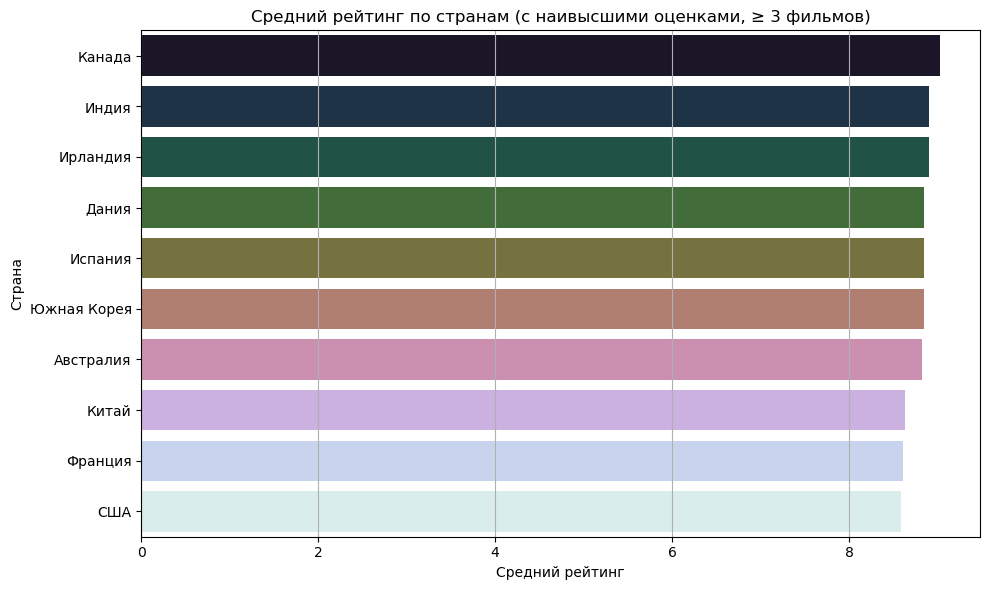

In [3]:
# Загрузка данных
df = pd.read_csv("../data/processed/movies_clean.csv", converters={
    "Режиссер": ast.literal_eval,
    "Жанр": ast.literal_eval,
    "Продюсер": ast.literal_eval,
    "Сценарист": ast.literal_eval,
    "Композитор": ast.literal_eval,
    "Монтажер": ast.literal_eval,
    "Оператор": ast.literal_eval,
    "Страна": ast.literal_eval,
    "Формат": ast.literal_eval,
    "title_lemmas": ast.literal_eval
})

plot_avg_rating_by_country(df, min_count=3, top_n=10)

#### Зависимость рейтинга от количества голосов

Диаграмма рассеяния позволяет визуально оценить, как количество голосов влияет на итоговый рейтинг фильма.

**Почему это важно:**
- Рейтинг, полученный по 5–10 голосам, может быть сильно искажён (часто выше среднего)
- Фильмы с большим количеством голосов имеют более устойчивые и достоверные оценки

**Проблема визуализации:**
- Распределение количества голосов сильно скошено: многие фильмы имеют 10–100 голосов, а отдельные — тысячи
- На обычном графике это вызывает "скопление" точек в левом углу

**Решение:**
- Используем логарифмическое преобразование `log10(votes + 1)`
- Это позволяет равномерно распределить данные по оси X
- Мы можем сравнивать фильмы разной популярности на одной шкале и выявлять паттерны

**Цель анализа:**
- Проверить, подтверждается ли гипотеза: малопопулярные фильмы получают необоснованно высокие рейтинги
- Оценить степень связи между популярностью и качеством (по мнению зрителей)


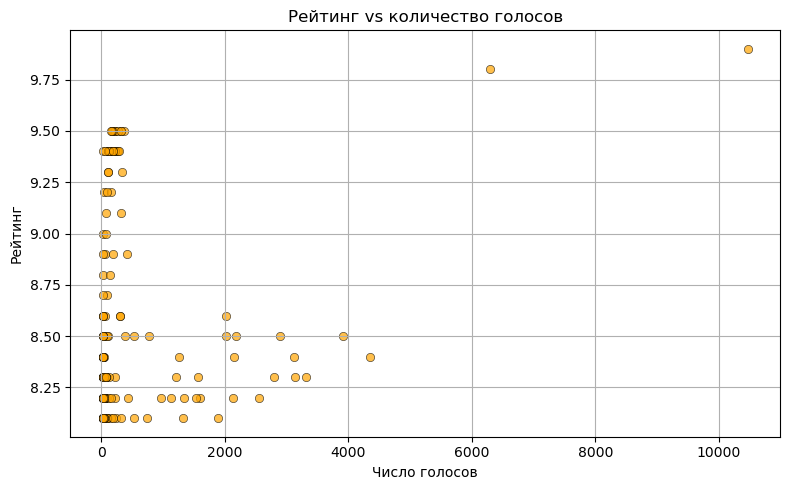

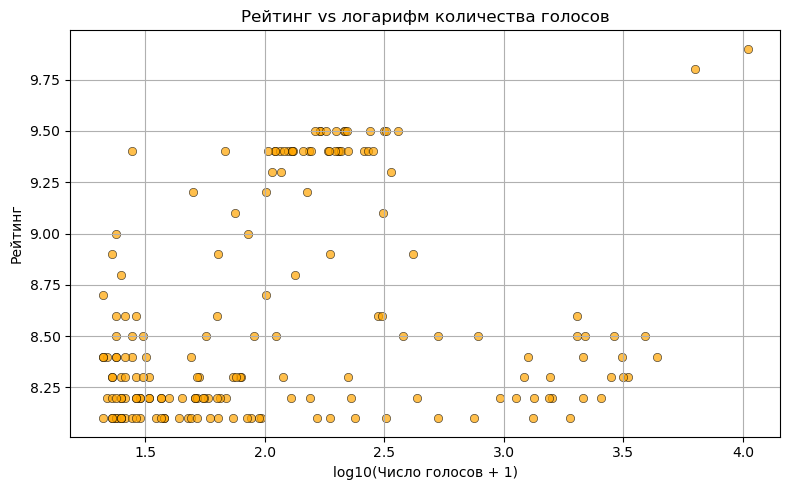

In [2]:
# Загрузка данных
df = pd.read_csv("../data/processed/movies_clean.csv", converters={
    "Режиссер": ast.literal_eval,
    "Жанр": ast.literal_eval,
    "Продюсер": ast.literal_eval,
    "Сценарист": ast.literal_eval,
    "Композитор": ast.literal_eval,
    "Монтажер": ast.literal_eval,
    "Оператор": ast.literal_eval,
    "Страна": ast.literal_eval,
    "Формат": ast.literal_eval,
    "title_lemmas": ast.literal_eval
})

# В обычной шкале
plot_rating_vs_votes(df)

# В логарифмической шкале
plot_rating_vs_votes(df, log_scale=True)

#### Зависимость рейтинга от хронометража

Проверим, как длительность фильма влияет на восприятие зрителями.

Есть предположение, что:
- слишком короткие фильмы могут выглядеть незавершёнными
- слишком длинные — утомлять зрителя
- существует "оптимальный" диапазон длительности

На диаграмме рассеяния можно визуально выявить тренды и возможные кластеры.
Мы исключаем явные выбросы, ограничив длительность от 40 до 180 минут.


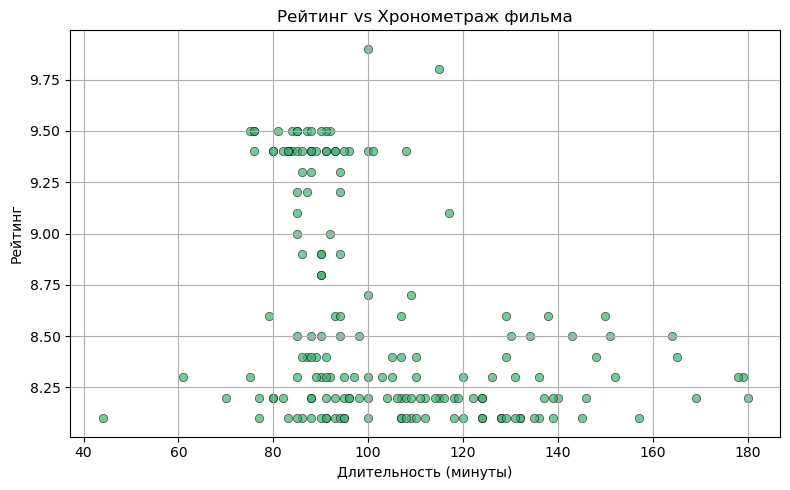

In [2]:
# Загрузка данных
df = pd.read_csv("../data/processed/movies_clean.csv", converters={
    "Режиссер": ast.literal_eval,
    "Жанр": ast.literal_eval,
    "Продюсер": ast.literal_eval,
    "Сценарист": ast.literal_eval,
    "Композитор": ast.literal_eval,
    "Монтажер": ast.literal_eval,
    "Оператор": ast.literal_eval,
    "Страна": ast.literal_eval,
    "Формат": ast.literal_eval,
    "title_lemmas": ast.literal_eval
})

plot_rating_vs_runtime(df, min_runtime=40, max_runtime=180)

#### Зависимость рейтинга от популярности фильма

Проанализируем, как соотносится зрительский интерес с оценкой фильма.

Мы используем два признака:
- **Число зрителей в России**
- **Сборы в России**

Для устранения смещённости шкалы по X применяем логарифмирование.
Цель — проверить, получают ли более массовые фильмы более высокие или низкие оценки,
и существует ли вообще корреляция между коммерческим успехом и качеством по мнению зрителей.


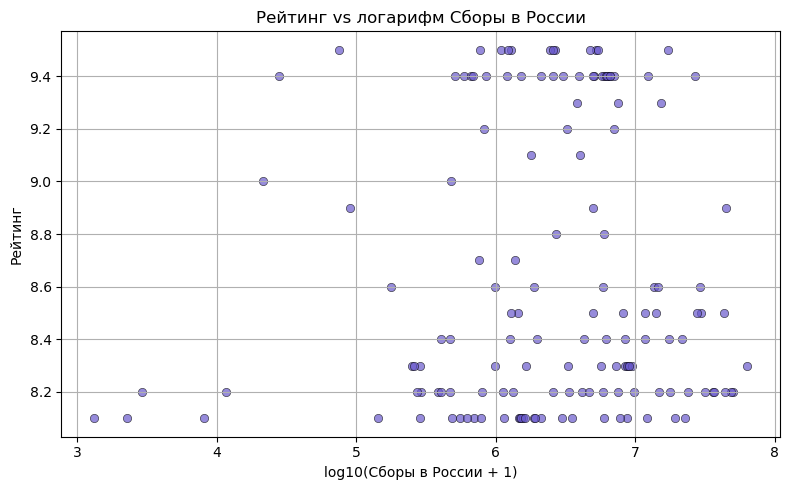

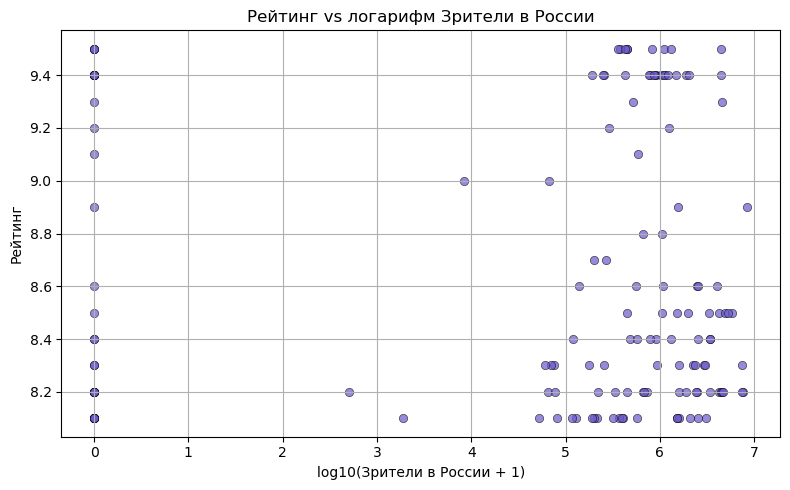

In [2]:
# Загрузка данных
df = pd.read_csv("../data/processed/movies_clean.csv", converters={
    "Режиссер": ast.literal_eval,
    "Жанр": ast.literal_eval,
    "Продюсер": ast.literal_eval,
    "Сценарист": ast.literal_eval,
    "Композитор": ast.literal_eval,
    "Монтажер": ast.literal_eval,
    "Оператор": ast.literal_eval,
    "Страна": ast.literal_eval,
    "Формат": ast.literal_eval,
    "title_lemmas": ast.literal_eval
})

# Связь рейтинга и сборов
plot_rating_vs_popularity(df, column="Сборы в России")

# Связь рейтинга и числа зрителей
plot_rating_vs_popularity(df, column="Зрители в России")

#### Зависимость рейтинга от длины названия

Проверим, влияет ли длина названия фильма на его восприятие зрителями.

Мы рассчитываем:
- длину названия в символах
- количество слов (лемм) после обработки текста

Возможно, короткие и лаконичные названия воспринимаются лучше,
а слишком длинные — воспринимаются как перегруженные.

Диаграммы помогут выявить наличие или отсутствие зависимости.


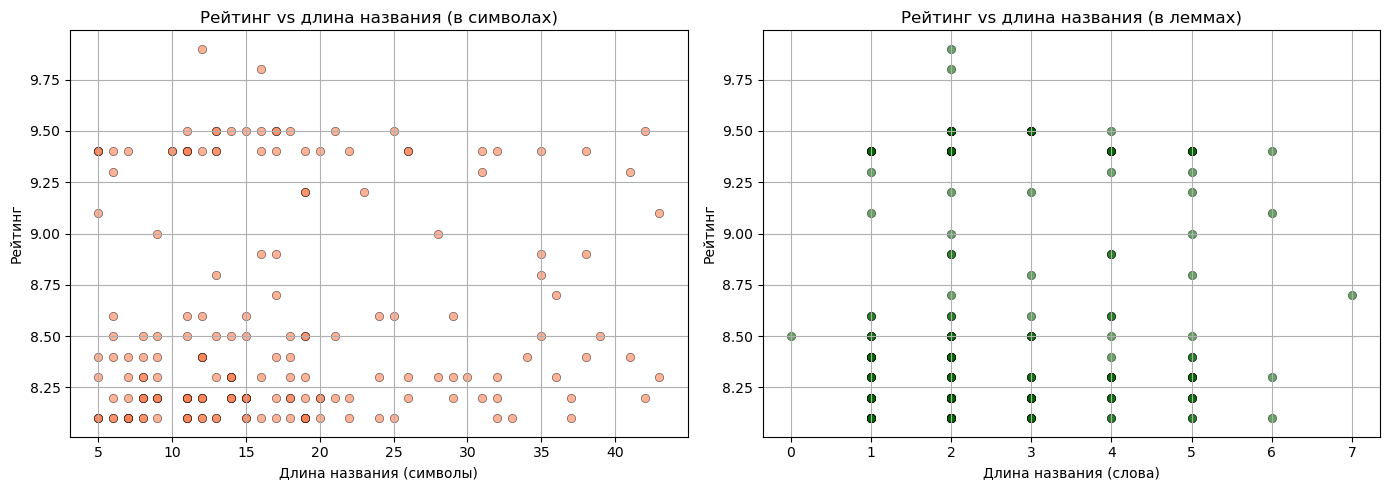

In [2]:
# Загрузка данных
df = pd.read_csv("../data/processed/movies_clean.csv", converters={
    "Режиссер": ast.literal_eval,
    "Жанр": ast.literal_eval,
    "Продюсер": ast.literal_eval,
    "Сценарист": ast.literal_eval,
    "Композитор": ast.literal_eval,
    "Монтажер": ast.literal_eval,
    "Оператор": ast.literal_eval,
    "Страна": ast.literal_eval,
    "Формат": ast.literal_eval,
    "title_lemmas": ast.literal_eval
})

plot_rating_vs_title_length(df)

#### Частотный анализ лемм в названиях фильмов

Здесь мы анализируем, какие слова чаще всего встречаются в названиях фильмов.

Для этого были использованы лемматизированные названия — очищенные от пунктуации, приведённые к начальной форме.

Анализ может выявить тематику и стиль в наименованиях, повторяющиеся образы и жанровые маркеры.


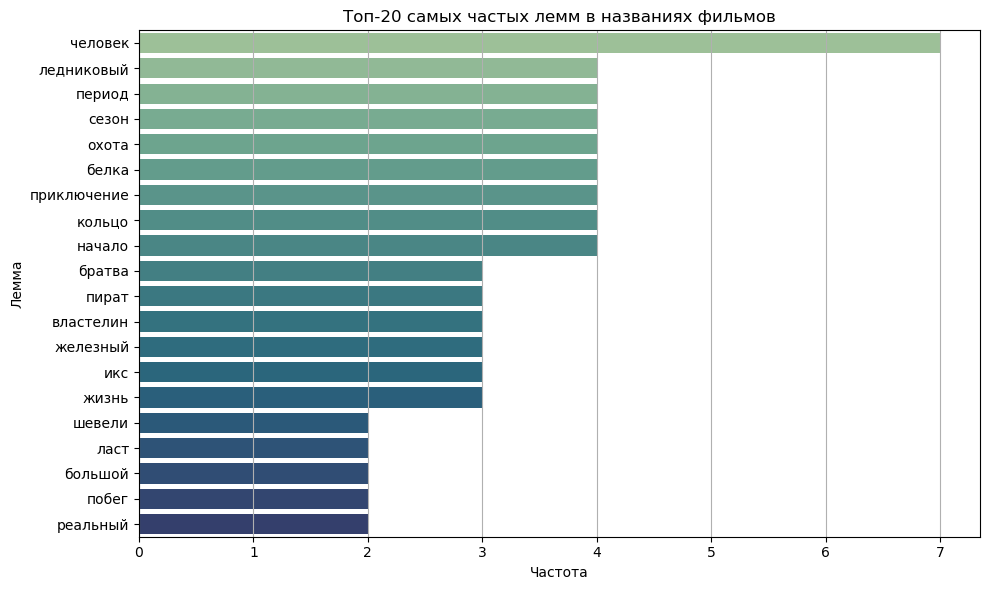

In [3]:
# Загрузка данных
df = pd.read_csv("../data/processed/movies_clean.csv", converters={
    "Режиссер": ast.literal_eval,
    "Жанр": ast.literal_eval,
    "Продюсер": ast.literal_eval,
    "Сценарист": ast.literal_eval,
    "Композитор": ast.literal_eval,
    "Монтажер": ast.literal_eval,
    "Оператор": ast.literal_eval,
    "Страна": ast.literal_eval,
    "Формат": ast.literal_eval,
    "title_lemmas": ast.literal_eval
})

plot_top_lemmas(df, top_n=20)

### Сравнение лемм в названиях «успешных» и менее успешных фильмов по рейтингу

Анализ частотных лемм показал заметные различия в тематике названий:

- У **фильмов с рейтингом ≥ 8.5** чаще встречаются слова, связанные с юмором, динамикой и приключениями:
  - «сезон», «ледниковый», «охота», «побег», «приключение», «пират», «реальный», «братва»
  - такие слова задают лёгкий, развлекательный или приключенческий тон

- У **фильмов с рейтингом ≤ 8.4** преобладают слова с более серьёзной или мрачной окраской:
  - «жизнь», «тема», «чёрный», «тёмный», «дракон», «область», «кольцо», «начало»
  - часто встречаются также «властелин», «икс», «железный» — названия более пафосные и эпические

Это может указывать на связь между стилистикой названия и восприятием фильма:
- более лёгкие и образные названия ассоциируются с высокими оценками
- серьёзные, пафосные или абстрактные — с более сдержанными

Тем не менее, это скорее корреляция, чем причинная связь, и требует дальнейшей проверки.

Важно подметить, что в выборке очень мало фильмов с рейтингом меньше 8.5. Поэтому второй график может быть не совсем
релевантным.


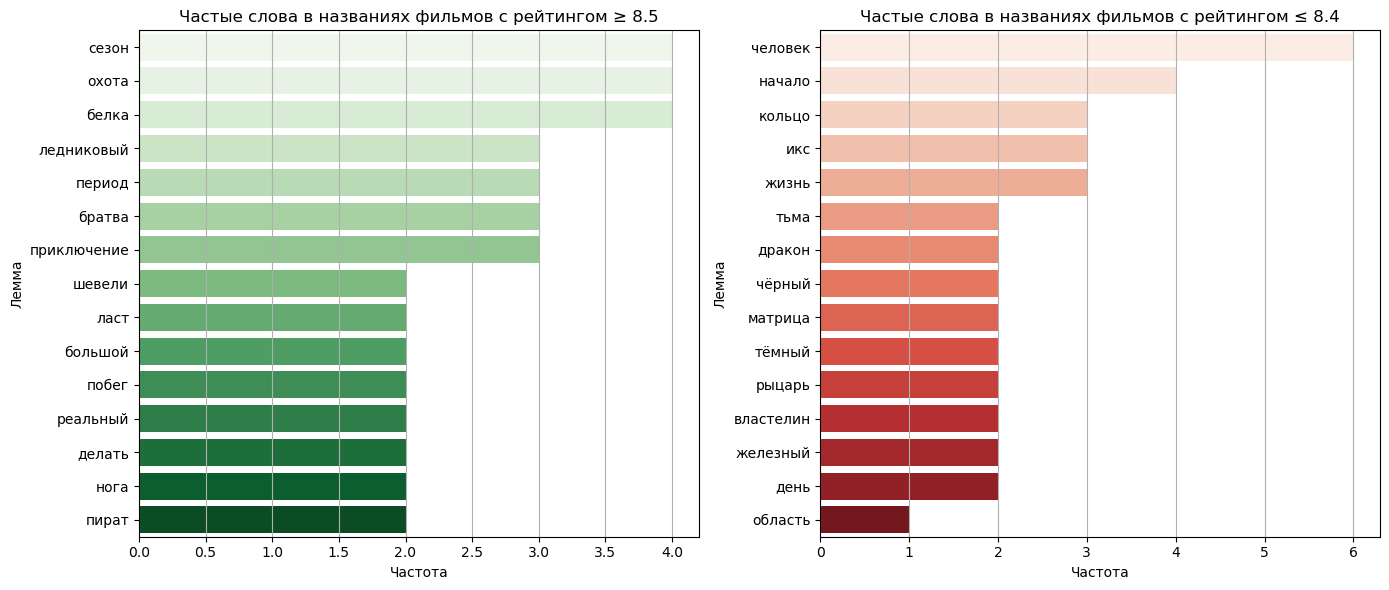

In [8]:
# Загрузка данных
df = pd.read_csv("../data/processed/movies_clean.csv", converters={
    "Режиссер": ast.literal_eval,
    "Жанр": ast.literal_eval,
    "Продюсер": ast.literal_eval,
    "Сценарист": ast.literal_eval,
    "Композитор": ast.literal_eval,
    "Монтажер": ast.literal_eval,
    "Оператор": ast.literal_eval,
    "Страна": ast.literal_eval,
    "Формат": ast.literal_eval,
    "title_lemmas": ast.literal_eval
})

compare_lemmas_by_rating(df, high_thresh=8.5, low_thresh=8.4, top_n=15)

## Streamlit-дэшборд

В рамках проекта также был разработан интерактивный дэшборд на **Streamlit**.

Он позволяет:
- исследовать данные без необходимости запускать ноутбук,
- интерактивно переключаться между ключевыми этапами анализа (EDA, зависимости, выводы),
- фильтровать и визуализировать данные в реальном времени.

### Как запустить дэшборд:

1. Установите зависимости (если ещё не установлены):
```bash
pip install streamlit
```
2. Запустите дэшборд из корневой папки проекта:
```bash
streamlit run dashboard/dashboard.py
```
3. Откроется браузер с дэшбордом, где можно исследовать данные и визуализации.

Дэшборд включает:
- Навигацию по разделам
- Интерактивные таблицы и графики
- Текстовые выводы и рекомендации


## Выводы 

### Где различия оказались невыраженными — и почему

Несмотря на большое количество проведённых сравнений, в ряде случаев **не было найдено значимых различий или устойчивых зависимостей**. Это важно интерпретировать правильно.

---

#### 1. Длина названия vs рейтинг

- Анализ длины названия (в символах и словах) **не показал заметной корреляции** с рейтингом.
- Вероятно, восприятие названия определяется не столько длиной, сколько смыслом и контекстом.
- Также возможно, что из-за ограниченности выборки названия имеют схожую структуру (топ-фильмы избегают «плохих» заголовков).

---

#### 2. Рейтинг vs хронометраж

- Распределение рейтингов по длительности фильма **не даёт чёткой зависимости**.
- Фильмы с разной длиной (от 70 до 150 минут) встречаются как среди высоко оценённых, так и менее популярных.
- Причина может крыться в жанровом разнообразии: у комедий, мультфильмов, драм и экшенов — разные нормы длительности.

---

#### 3. Рейтинг vs сборы и число зрителей

- Несмотря на ожидания, **нет чёткой связи** между популярностью фильма и его рейтингом.
- Это можно объяснить тем, что в выборке почти нет откровенно неудачных или кассовых провалов.
- Кроме того, выборка ограничена **только высоко оценёнными фильмами**, что снижает контраст.

---

#### 4. Разделение лемм между "успешными" и "менее успешными" фильмами

- Хотя визуально леммы частично отличаются, **яркой смысловой границы между группами не наблюдается**.
- Причина может быть в следующем:
  - **граница между “высоким” и “не очень высоким” рейтингом выбрана слишком близко (8.5 vs 8.4)**
  - выборка **не содержит низкорейтинговых фильмов** вообще — это сильно снижает эффект контраста

---

### Влияние выборки

- Исследуемая выборка содержит только **топ-фильмы по версии сайта** (все с рейтингом ~8.0+).
- Это делает её неравномерной и **смещённой в сторону "лучших" фильмов**.
- Из-за этого:
  - не видны границы между хорошими и плохими фильмами,
  - многие признаки «сглаживаются», различия уменьшаются,
  - выводы нельзя напрямую обобщать на весь кинематограф.

---

### Вывод

Исследование дало интересные наблюдения, но его результаты нужно трактовать **с осторожностью** из-за характера выборки.
Для более репрезентативного анализа стоит расширить данные за пределы топ-листа и включить фильмы с более широким диапазоном рейтингов.


## Обсуждение

#### Что мы хотели сделать

Целью исследования было проанализировать страницы фильмов с сайта FilmPro,
собрать структурированные данные, выявить зависимости между рейтингом и характеристиками фильма,
а также изучить влияние текстовых признаков (в частности, названий фильмов) на восприятие.

Хотелось понять:
- какие жанры, авторы, страны связаны с высоким рейтингом,
- влияет ли хронометраж, число голосов или кассовые сборы на итоговую оценку,
- несут ли заголовки фильмов смысловую или эмоциональную «нагрузку», отражающую качество.

#### Что удалось

- Удалось реализовать полный **пайплайн от парсинга до анализа**: автоматический сбор, очистка, нормализация и визуализация данных.
- Были построены детальные графики по рейтингу, голосам, хронометражу, жанрам, странам, режиссёрам.
- Удалось выделить **частотные паттерны** в названиях успешных фильмов (например, слова «приключение», «пират», «ледниковый»).
- Найдено несколько устойчивых закономерностей, например:
  - мультфильмы и комедии чаще получают высокие оценки,
  - малое число голосов связано с нестабильно высокими рейтингами.

#### Что не удалось

- В выборке отсутствовали фильмы с низкими рейтингами, из-за чего:
  - **исчез контраст** между «хорошими» и «плохими» фильмами,
  - невозможно было провести полноценную классификацию или бинарное сравнение.
- Многие признаки (например, сборы или зрители) содержали **много пропусков**, что снизило их аналитическую ценность.
- Не удалось вывести чёткие зависимости между рейтингом и хронометражем, длиной названия или кассовыми результатами — скорее всего, из-за **ограниченного объёма данных** и их предвзятости (топ-лист).

#### Как можно улучшить исследование

- Использовать **более широкую выборку**: добавить фильмы среднего и низкого уровня рейтинга, что сделает модель и выводы более сбалансированными.
- Расширить парсинг — собирать не только страницу фильма, но и отзывы, трейлеры, информацию о наградах и т.п.
- Применить **машинное обучение** для предсказания рейтинга по жанру, авторам, длине и леммам в названии.
- Выбрать более надежный источник данных: с более широкой базой фильмов и более точными метаданными, с большим числом
 пользовательских оценок.

#### Кому может быть полезно это исследование

- **Пользователям** — поможет ориентироваться в выборе фильмов по жанрам, авторам, странам.
- **Контент-платформам** — может быть использовано для рекомендаций и оценки интереса к фильмам по названию и метаданным.
- **Продюсерам и маркетологам** — при разработке названия, позиционирования, определения целевой аудитории.
- **Исследователям** — как пример переноса текстового анализа и визуальной разведки данных на киноиндустрию.

